In [2]:
"""
# 04 — CNN vs Características Clásicas de Visión por Computadora

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras + scikit-learn  
"Dataset:" MNIST
---
## ¿Qué vamos a aprender en este notebook?
1. Qué son las características clásicas de visión por computadora
2. Cómo extraer características HOG y LBP manualmente
3. Entrenar clasificadores clásicos (SVM, Random Forest) sobre esas características
4. Comparar su performance contra la CNN del notebook 02
5. Entender por qué el deep learning superó a los métodos tradicionales
---
Este notebook responde una pregunta clave: ¿qué ventaja real tiene una CNN sobre los métodos que existían antes del deep learning?
## 1. Características clásicas de visión por computadora

Antes del deep learning, el pipeline estándar para clasificación
de imágenes era:
Imagen → Extracción manual    → Clasificador   → Predicción
de características     clásico
(HOG, LBP, SIFT)      (SVM, RF)

El problema era que las características había que "diseñarlas a mano"
— un experto decidía qué era relevante extraer de la imagen.
### Las características más usadas
| Característica | Qué detecta | Fortaleza |
|---|---|---|
| "HOG" (Histogram of Oriented Gradients) | Bordes y gradientes por zonas | Formas y contornos |
| "LBP" (Local Binary Patterns) | Texturas locales | Patrones de textura |
| "SIFT" (Scale Invariant Feature Transform) | Puntos clave invariantes | Escala y rotación |

Hoy vamos a trabajar con "HOG" y "LBP" porque son los más simples de implementar y entender intuitivamente.
"""

'\n# 04 — CNN vs Características Clásicas de Visión por Computadora\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras + scikit-learn  \n"Dataset:" MNIST\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué son las características clásicas de visión por computadora\n2. Cómo extraer características HOG y LBP manualmente\n3. Entrenar clasificadores clásicos (SVM, Random Forest) sobre esas características\n4. Comparar su performance contra la CNN del notebook 02\n5. Entender por qué el deep learning superó a los métodos tradicionales\n---\nEste notebook responde una pregunta clave: ¿qué ventaja real tiene una CNN sobre los métodos que existían antes del deep learning?\n## 1. Características clásicas de visión por computadora\n\nAntes del deep learning, el pipeline estándar para clasificación\nde imágenes era:\nImagen → Extracción manual    → Clasificador   → Predicción\nde características     clásico\n(HOG, LBP, SIFT)      (SVM, RF)\n\nEl problema er

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
import time

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [4]:
"""
## 2. Cargar los datos

Vamos a usar el mismo MNIST de los notebooks anteriores.
Para este notebook necesitamos dos formatos distintos:
| Formato | Shape | Para qué |
|---|---|---|
| "Imágenes 2D" | (N, 28, 28) | Extraer HOG y LBP con skimage |
| "Imágenes 4D" | (N, 28, 28, 1) | Alimentar la CNN de Keras |
Los clasificadores clásicos reciben vectores 1D como entrada, por eso después de extraer las características vamos a aplanarlas.
La CNN en cambio recibe la imagen con su estructura espacial intacta.
"""

'\n## 2. Cargar los datos\n\nVamos a usar el mismo MNIST de los notebooks anteriores.\nPara este notebook necesitamos dos formatos distintos:\n| Formato | Shape | Para qué |\n|---|---|---|\n| "Imágenes 2D" | (N, 28, 28) | Extraer HOG y LBP con skimage |\n| "Imágenes 4D" | (N, 28, 28, 1) | Alimentar la CNN de Keras |\nLos clasificadores clásicos reciben vectores 1D como entrada, por eso después de extraer las características vamos a aplanarlas.\nLa CNN en cambio recibe la imagen con su estructura espacial intacta.\n'

In [5]:
# Cargar MNIST
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test_raw  = X_test_raw.astype('float32')  / 255.0

# Formato 4D para la CNN
X_train_cnn = X_train_raw[..., np.newaxis]
X_test_cnn  = X_test_raw[..., np.newaxis]

# Separar validación
X_val_cnn   = X_train_cnn[50000:]
X_train_cnn = X_train_cnn[:50000]
X_val_raw   = X_train_raw[50000:]
X_train_raw = X_train_raw[:50000]
y_val       = y_train[50000:]
y_train     = y_train[:50000]

print(f"Train: {X_train_raw.shape[0]} muestras")
print(f"Val:   {X_val_raw.shape[0]} muestras")
print(f"Test:  {X_test_raw.shape[0]} muestras")
print(f"\nFormato 2D (clásico): {X_train_raw.shape}")
print(f"Formato 4D (CNN):     {X_train_cnn.shape}")

Train: 50000 muestras
Val:   10000 muestras
Test:  10000 muestras

Formato 2D (clásico): (50000, 28, 28)
Formato 4D (CNN):     (50000, 28, 28, 1)


In [6]:
"""
## 3. HOG — Histogram of Oriented Gradients
HOG describe la forma de un objeto capturando la "dirección e intensidad
de los bordes" en zonas locales de la imagen.
### ¿Cómo funciona?
1. Divide la imagen en celdas pequeñas (ej: 4×4 píxeles)
2. En cada celda calcula los gradientes (cambios de intensidad)
3. Construye un histograma de direcciones de gradiente por celda
4. Concatena todos los histogramas → vector de características
Imagen (28×28)
↓
Dividir en celdas (4×4)
↓
Calcular gradientes por celda
↓
Histograma de orientaciones por celda
↓
Vector HOG (longitud fija)  →  Clasificador

### ¿Por qué funciona para dígitos?
Los dígitos se distinguen principalmente por su "forma y contorno", que es exactamente lo que HOG captura bien.
"""

'\n## 3. HOG — Histogram of Oriented Gradients\nHOG describe la forma de un objeto capturando la "dirección e intensidad\nde los bordes" en zonas locales de la imagen.\n### ¿Cómo funciona?\n1. Divide la imagen en celdas pequeñas (ej: 4×4 píxeles)\n2. En cada celda calcula los gradientes (cambios de intensidad)\n3. Construye un histograma de direcciones de gradiente por celda\n4. Concatena todos los histogramas → vector de características\nImagen (28×28)\n↓\nDividir en celdas (4×4)\n↓\nCalcular gradientes por celda\n↓\nHistograma de orientaciones por celda\n↓\nVector HOG (longitud fija)  →  Clasificador\n\n### ¿Por qué funciona para dígitos?\nLos dígitos se distinguen principalmente por su "forma y contorno", que es exactamente lo que HOG captura bien.\n'

In [7]:
def extract_hog_features(images):
    """Extrae características HOG de un conjunto de imágenes."""
    features = []
    for img in images:
        hog_feat = hog(
            img,
            orientations=8,        # Número de bins en el histograma
            pixels_per_cell=(4,4), # Tamaño de cada celda
            cells_per_block=(2,2), # Normalización por bloques
            visualize=False
        )
        features.append(hog_feat)
    return np.array(features)

# Extraer HOG para train y test
print("Extrayendo características HOG...")

start = time.time()
X_train_hog = extract_hog_features(X_train_raw)
X_test_hog  = extract_hog_features(X_test_raw)
elapsed = time.time() - start

print(f"Tiempo de extracción: {elapsed:.1f} segundos")
print(f"Shape HOG train: {X_train_hog.shape}")
print(f"Shape HOG test:  {X_test_hog.shape}")
print(f"Cada imagen → vector de {X_train_hog.shape[1]} características")

Extrayendo características HOG...
Tiempo de extracción: 50.6 segundos
Shape HOG train: (50000, 1152)
Shape HOG test:  (10000, 1152)
Cada imagen → vector de 1152 características


In [8]:
"""
## 4. Visualizar HOG
Antes de entrenar un clasificador sobre las características HOG,
vamos a visualizarlas para entender qué información capturan.
"skimage" nos permite obtener una "imagen de visualización" del HOG
que muestra las orientaciones de gradiente detectadas en cada celda.
En la visualización HOG vas a ver líneas pequeñas en cada celda que indican la dirección dominante del gradiente-básicamente los bordes de la figura desde distintos ángulos.
"""

'\n## 4. Visualizar HOG\nAntes de entrenar un clasificador sobre las características HOG,\nvamos a visualizarlas para entender qué información capturan.\n"skimage" nos permite obtener una "imagen de visualización" del HOG\nque muestra las orientaciones de gradiente detectadas en cada celda.\nEn la visualización HOG vas a ver líneas pequeñas en cada celda que indican la dirección dominante del gradiente-básicamente los bordes de la figura desde distintos ángulos.\n'

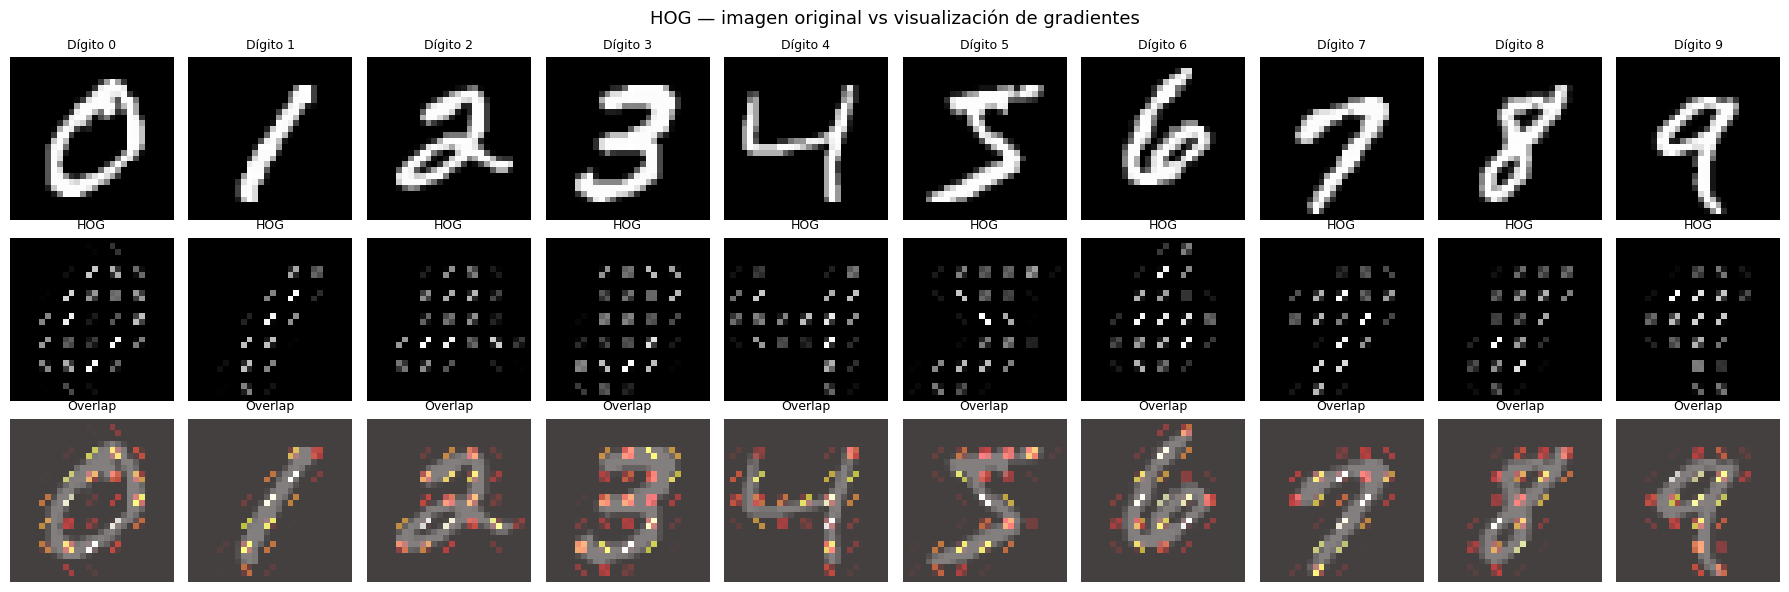

In [9]:
# Visualizar HOG para un ejemplo de cada dígito
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('HOG — imagen original vs visualización de gradientes', fontsize=13)

for digit in range(10):
    # Obtener un ejemplo de cada dígito
    idx = np.where(y_train == digit)[0][0]
    img = X_train_raw[idx]

    # Calcular HOG con visualización
    hog_feat, hog_img = hog(
        img,
        orientations=8,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True
    )

    # Mejorar contraste de la visualización
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    # Fila 1: imagen original
    axes[0, digit].imshow(img, cmap='gray')
    axes[0, digit].set_title(f'Dígito {digit}', fontsize=9)
    axes[0, digit].axis('off')

    # Fila 2: visualización HOG
    axes[1, digit].imshow(hog_img_rescaled, cmap='gray')
    axes[1, digit].set_title('HOG', fontsize=9)
    axes[1, digit].axis('off')

    # Fila 3: superposición
    axes[2, digit].imshow(img, cmap='gray', alpha=0.5)
    axes[2, digit].imshow(hog_img_rescaled, cmap='hot', alpha=0.5)
    axes[2, digit].set_title('Overlap', fontsize=9)
    axes[2, digit].axis('off')

plt.tight_layout()
plt.savefig('../figures/04_hog_visualizacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
"""
## 5. LBP — Local Binary Patterns

LBP describe la "textura local" de una imagen comparando cada píxel
con sus vecinos y codificando el resultado como un número binario.
### ¿Cómo funciona?
1. Para cada píxel, compara su valor con los P vecinos en un radio R
2. Si el vecino es mayor o igual → 1, si es menor → 0
3. Concatena los bits → número binario → valor LBP
4. Construye un histograma de valores LBP sobre toda la imagen
Vecinos del píxel central (valor=50):
┌──────────────────────────┐
│  30  80  20              │
│  60  50  90   →  01011101  →  valor LBP
│  40  70  10              │
└──────────────────────────┘
<50  >50  <50
0    1    0  → bits
### ¿Por qué funciona para dígitos?
Captura patrones de textura locales que complementan la información
de forma que captura HOG.
"""

'\n## 5. LBP — Local Binary Patterns\n\nLBP describe la "textura local" de una imagen comparando cada píxel\ncon sus vecinos y codificando el resultado como un número binario.\n### ¿Cómo funciona?\n1. Para cada píxel, compara su valor con los P vecinos en un radio R\n2. Si el vecino es mayor o igual → 1, si es menor → 0\n3. Concatena los bits → número binario → valor LBP\n4. Construye un histograma de valores LBP sobre toda la imagen\nVecinos del píxel central (valor=50):\n┌──────────────────────────┐\n│  30  80  20              │\n│  60  50  90   →  01011101  →  valor LBP\n│  40  70  10              │\n└──────────────────────────┘\n<50  >50  <50\n0    1    0  → bits\n### ¿Por qué funciona para dígitos?\nCaptura patrones de textura locales que complementan la información\nde forma que captura HOG.\n'

In [11]:
def extract_lbp_features(images, P=8, R=1, n_bins=256):
    """Extrae características LBP de un conjunto de imágenes."""
    features = []
    for img in images:
        # Calcular LBP
        lbp = local_binary_pattern(img, P=P, R=R, method='uniform')
        # Construir histograma de valores LBP
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                               range=(0, n_bins), density=True)
        features.append(hist)
    return np.array(features)

# Extraer LBP para train y test
print("Extrayendo características LBP...")

start = time.time()
X_train_lbp = extract_lbp_features(X_train_raw)
X_test_lbp  = extract_lbp_features(X_test_raw)
elapsed = time.time() - start

print(f"Tiempo de extracción: {elapsed:.1f} segundos")
print(f"Shape LBP train: {X_train_lbp.shape}")
print(f"Shape LBP test:  {X_test_lbp.shape}")
print(f"Cada imagen → vector de {X_train_lbp.shape[1]} características")

Extrayendo características LBP...


C:\Users\Peter\ml_env\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Tiempo de extracción: 18.8 segundos
Shape LBP train: (50000, 256)
Shape LBP test:  (10000, 256)
Cada imagen → vector de 256 características


In [12]:
"""
## 6. Visualizar LBP

A diferencia de HOG, la visualización de LBP muestra directamente
el "mapa de valores LBP" — cada píxel toma un valor entre 0 y 255
dependiendo del patrón de sus vecinos.

LBP es especialmente sensible a los "bordes y esquinas" zonas donde 
hay cambios bruscos de intensidad van a tener
> valores LBP distintos a zonas uniformes.
"""

'\n## 6. Visualizar LBP\n\nA diferencia de HOG, la visualización de LBP muestra directamente\nel "mapa de valores LBP" — cada píxel toma un valor entre 0 y 255\ndependiendo del patrón de sus vecinos.\n\nLBP es especialmente sensible a los "bordes y esquinas" zonas donde \nhay cambios bruscos de intensidad van a tener\n> valores LBP distintos a zonas uniformes.\n'

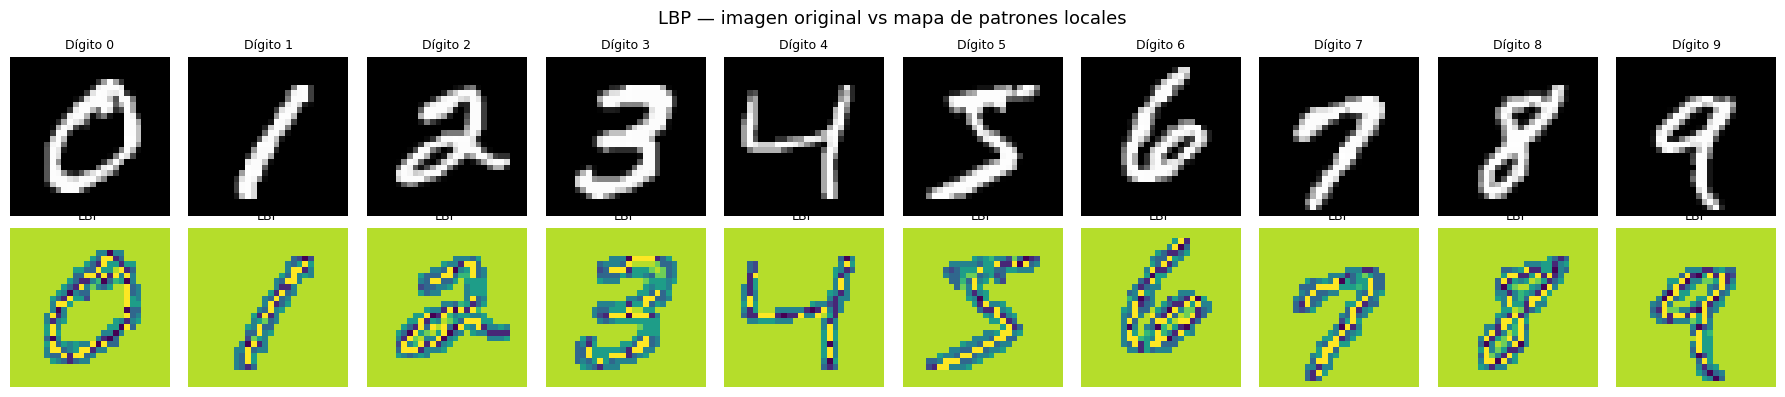

In [13]:
# Visualizar LBP para un ejemplo de cada dígito
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('LBP — imagen original vs mapa de patrones locales', fontsize=13)

for digit in range(10):
    # Obtener un ejemplo de cada dígito
    idx = np.where(y_train == digit)[0][0]
    img = X_train_raw[idx]

    # Calcular LBP
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')

    # Fila 1: imagen original
    axes[0, digit].imshow(img, cmap='gray')
    axes[0, digit].set_title(f'Dígito {digit}', fontsize=9)
    axes[0, digit].axis('off')

    # Fila 2: mapa LBP
    axes[1, digit].imshow(lbp, cmap='viridis')
    axes[1, digit].set_title('LBP', fontsize=9)
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('../figures/04_lbp_visualizacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
"""
## 7. Entrenar clasificadores clásicos

Ahora vamos a entrenar clasificadores sobre las características
que extrajimos. Vamos a probar dos combinaciones:
| Características | Clasificador |
|---|---|
| HOG | SVM con kernel RBF |
| LBP | Random Forest |
### ¿Por qué SVM para HOG?
SVM es históricamente el clasificador que mejor funciona con HOG —
la combinación HOG + SVM fue el estado del arte en detección
de personas antes del deep learning.
### ¿Por qué Random Forest para LBP?
Random Forest maneja bien características de histogramas como LBP
y es robusto ante features ruidosas o redundantes.
Vamos a usar un subconjunto del train para que el entrenamiento
no tarde demasiado — los SVMs escalan mal con datasets grandes.
"""

'\n## 7. Entrenar clasificadores clásicos\n\nAhora vamos a entrenar clasificadores sobre las características\nque extrajimos. Vamos a probar dos combinaciones:\n| Características | Clasificador |\n|---|---|\n| HOG | SVM con kernel RBF |\n| LBP | Random Forest |\n### ¿Por qué SVM para HOG?\nSVM es históricamente el clasificador que mejor funciona con HOG —\nla combinación HOG + SVM fue el estado del arte en detección\nde personas antes del deep learning.\n### ¿Por qué Random Forest para LBP?\nRandom Forest maneja bien características de histogramas como LBP\ny es robusto ante features ruidosas o redundantes.\nVamos a usar un subconjunto del train para que el entrenamiento\nno tarde demasiado — los SVMs escalan mal con datasets grandes.\n'

In [15]:
# Usamos 10,000 muestras para que el SVM no tarde demasiado
N_TRAIN = 10000

# Escalar características — importante para SVM
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog[:N_TRAIN])
X_test_hog_scaled  = scaler_hog.transform(X_test_hog)

# Entrenar SVM con HOG
print("Entrenando SVM + HOG...")
start = time.time()

svm_hog = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_hog.fit(X_train_hog_scaled, y_train[:N_TRAIN])

elapsed = time.time() - start
print(f"Tiempo de entrenamiento: {elapsed:.1f} segundos")

# Evaluar
y_pred_hog = svm_hog.predict(X_test_hog_scaled)
acc_hog = accuracy_score(y_test, y_pred_hog)
print(f"\nSVM + HOG Test Accuracy: {acc_hog:.4f} ({acc_hog*100:.1f}%)")

Entrenando SVM + HOG...
Tiempo de entrenamiento: 36.0 segundos

SVM + HOG Test Accuracy: 0.9696 (97.0%)


In [16]:
# Entrenar Random Forest con LBP
print("Entrenando Random Forest + LBP...")
start = time.time()

rf_lbp = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1  # Usar todos los cores disponibles
)
rf_lbp.fit(X_train_lbp[:N_TRAIN], y_train[:N_TRAIN])

elapsed = time.time() - start
print(f"Tiempo de entrenamiento: {elapsed:.1f} segundos")

# Evaluar
y_pred_lbp = rf_lbp.predict(X_test_lbp)
acc_lbp = accuracy_score(y_test, y_pred_lbp)
print(f"\nRandom Forest + LBP Test Accuracy: {acc_lbp:.4f} ({acc_lbp*100:.1f}%)")

Entrenando Random Forest + LBP...
Tiempo de entrenamiento: 1.7 segundos

Random Forest + LBP Test Accuracy: 0.4065 (40.6%)


In [17]:
"""
## 8. Comparación final — Métodos clásicos vs CNN
Tenemos los resultados de los métodos clásicos. Ahora vamos a
cargar la CNN del notebook 02 y evaluar sobre el mismo test set
para tener una comparación justa.
| Método | Características | Clasificador | Train samples |
|---|---|---|---|
| HOG + SVM | Manuales | SVM RBF | 10,000 |
| LBP + RF | Manuales | Random Forest | 10,000 |
| "CNN" | "Aprendidas" | "Red neuronal" | "50,000" |
Notá que los métodos clásicos usaron solo 10,000 muestras
de entrenamiento mientras la CNN usó 50,000. Vamos a tener
esto en cuenta al interpretar los resultados.
"""

'\n## 8. Comparación final — Métodos clásicos vs CNN\nTenemos los resultados de los métodos clásicos. Ahora vamos a\ncargar la CNN del notebook 02 y evaluar sobre el mismo test set\npara tener una comparación justa.\n| Método | Características | Clasificador | Train samples |\n|---|---|---|---|\n| HOG + SVM | Manuales | SVM RBF | 10,000 |\n| LBP + RF | Manuales | Random Forest | 10,000 |\n| "CNN" | "Aprendidas" | "Red neuronal" | "50,000" |\nNotá que los métodos clásicos usaron solo 10,000 muestras\nde entrenamiento mientras la CNN usó 50,000. Vamos a tener\nesto en cuenta al interpretar los resultados.\n'

In [18]:
# Cargar CNN del notebook 02
model_cnn = keras.models.load_model('../models/02_cnn_mnist.keras')

# Evaluar CNN sobre test set
y_pred_cnn_probs = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

print(f"CNN Test Accuracy: {acc_cnn:.4f} ({acc_cnn*100:.1f}%)")

# Tabla comparativa
print("\n" + "="*55)
print(f"{'Método':<25} {'Accuracy':>10} {'Train samples':>15}")
print("="*55)
print(f"{'LBP + Random Forest':<25} {acc_lbp*100:>9.1f}% {'10,000':>15}")
print(f"{'HOG + SVM':<25} {acc_hog*100:>9.1f}% {'10,000':>15}")
print(f"{'CNN':<25} {acc_cnn*100:>9.1f}% {'50,000':>15}")
print("="*55)

CNN Test Accuracy: 0.9895 (99.0%)

Método                      Accuracy   Train samples
LBP + Random Forest            40.6%          10,000
HOG + SVM                      97.0%          10,000
CNN                            99.0%          50,000


In [19]:
"""
## 9. Visualizar la comparación

Los números hablan claro, pero una visualización nos permite
comunicar los resultados de forma más impactante.
Vamos a graficar tres cosas:
- El accuracy de cada método
- La brecha entre métodos clásicos y CNN
- Los errores por clase para HOG+SVM vs CNN
"""

'\n## 9. Visualizar la comparación\n\nLos números hablan claro, pero una visualización nos permite\ncomunicar los resultados de forma más impactante.\nVamos a graficar tres cosas:\n- El accuracy de cada método\n- La brecha entre métodos clásicos y CNN\n- Los errores por clase para HOG+SVM vs CNN\n'

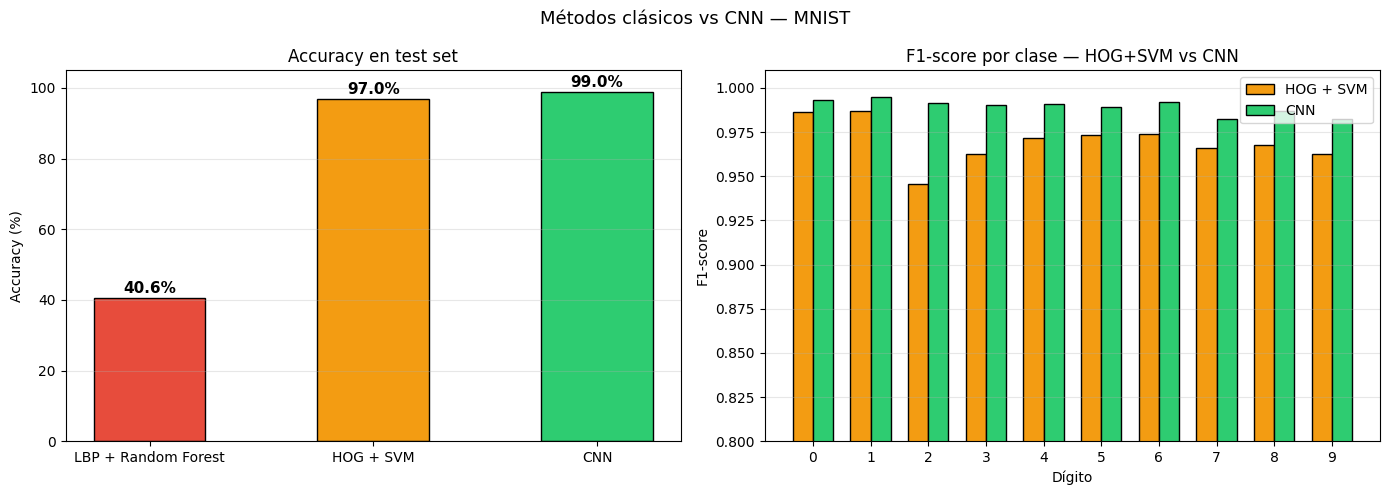

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Métodos clásicos vs CNN — MNIST', fontsize=13)

# --- Gráfico 1: Accuracy por método ---
metodos  = ['LBP + Random Forest', 'HOG + SVM', 'CNN']
accuracy = [acc_lbp * 100, acc_hog * 100, acc_cnn * 100]
colores  = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(metodos, accuracy, color=colores, width=0.5, edgecolor='black')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy en test set')
axes[0].grid(axis='y', alpha=0.3)

# Etiquetas sobre las barras
for bar, acc in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Gráfico 2: F1-score por clase HOG+SVM vs CNN ---
from sklearn.metrics import f1_score

f1_hog = f1_score(y_test, y_pred_hog, average=None)
f1_cnn = f1_score(y_test, y_pred_cnn, average=None)

x = np.arange(10)
width = 0.35

axes[1].bar(x - width/2, f1_hog, width, label='HOG + SVM', color='#f39c12', edgecolor='black')
axes[1].bar(x + width/2, f1_cnn, width, label='CNN',       color='#2ecc71', edgecolor='black')
axes[1].set_ylim(0.8, 1.01)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(i) for i in range(10)])
axes[1].set_xlabel('Dígito')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score por clase — HOG+SVM vs CNN')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/04_comparacion_final.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
"""
## 10. Interpretación de resultados
### ¿Qué nos dicen los números?
| Método | Accuracy | Conclusión |
|---|---|---|
| "LBP + RF" | ~40% | LBP captura textura pero no forma — inadecuado para dígitos |
| "HOG + SVM" | ~97% | HOG captura forma y contorno — muy competitivo |
| "CNN" | ~99% | Aprende características óptimas automáticamente |
### La diferencia clave no es solo el accuracy
La CNN supera a HOG+SVM por 2 puntos porcentuales, pero eso no cuenta toda la historia:
- "HOG requiere expertise": un experto decidió usar HOG, definió los parámetros (pixels_per_cell, orientations) y eligió SVM
- "CNN aprende sola": nadie le dijo qué detectar — aprendió los filtros óptimos directamente desde los datos
- "HOG no escala": en imágenes más complejas (objetos naturales, variaciones de iluminación) HOG se queda corto rápidamente
- "CNN escala": más datos + arquitecturas más profundas → más accuracy de forma casi automática
### ¿Por qué LBP falló tan rotundamente?
LBP fue diseñado para reconocimiento de texturas de rostros, no para clasificación de formas geométricas como los dígitos.
Es un recordatorio de que "no existe una característica universal" — cada descriptor fue diseñado para un problema específico.
Esa es exactamente la limitación que el deep learning superó.

## Resumen del notebook

| Concepto | Lo que aprendimos |
|---|---|
| "HOG" | Captura bordes y gradientes — muy efectivo para formas |
| "LBP" | Captura texturas locales — inadecuado para dígitos |
| "HOG + SVM" | Estado del arte pre-deep learning — 97% en MNIST |
| "CNN" | Aprende características óptimas automáticamente — 99% |
| "Ventaja real de CNN" | No necesita expertise manual ni diseño de features |
| "Escalabilidad" | CNN mejora con más datos y más profundidad |
---
## ¿Qué sigue?
En el "notebook 05" vamos a explorar "data augmentation" —
una técnica para artificialmente aumentar el tamaño del dataset
generando versiones modificadas de las imágenes existentes.
Es una de las herramientas más importantes para mejorar la
generalización de una CNN cuando los datos son escasos.
"""

'\n## 10. Interpretación de resultados\n### ¿Qué nos dicen los números?\n| Método | Accuracy | Conclusión |\n|---|---|---|\n| "LBP + RF" | ~40% | LBP captura textura pero no forma — inadecuado para dígitos |\n| "HOG + SVM" | ~97% | HOG captura forma y contorno — muy competitivo |\n| "CNN" | ~99% | Aprende características óptimas automáticamente |\n### La diferencia clave no es solo el accuracy\nLa CNN supera a HOG+SVM por 2 puntos porcentuales, pero eso no cuenta toda la historia:\n- "HOG requiere expertise": un experto decidió usar HOG, definió los parámetros (pixels_per_cell, orientations) y eligió SVM\n- "CNN aprende sola": nadie le dijo qué detectar — aprendió los filtros óptimos directamente desde los datos\n- "HOG no escala": en imágenes más complejas (objetos naturales, variaciones de iluminación) HOG se queda corto rápidamente\n- "CNN escala": más datos + arquitecturas más profundas → más accuracy de forma casi automática\n### ¿Por qué LBP falló tan rotundamente?\nLBP fue diseñ